<a href="https://colab.research.google.com/github/Rajendra9692385543/Data-Analytics-and-Machine-Learning/blob/Deep-Learning/DL_LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AveragePooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# Preprocess data
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# Function to create CNN model
def create_model(pooling_type='max'):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    if pooling_type == 'max':
        model.add(MaxPooling2D((2, 2)))
    elif pooling_type == 'average':
        model.add(AveragePooling2D((2, 2)))
    else:
        raise ValueError("Invalid pooling type")
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [ ]:
# Create models with different pooling types
model_max_pooling = create_model('max')
model_average_pooling = create_model('average')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Train models
history_max = model_max_pooling.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
history_average = model_average_pooling.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.5446 - loss: 1.2978 - val_accuracy: 0.5836 - val_loss: 1.1749
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 32ms/step - accuracy: 0.6126 - loss: 1.1048 - val_accuracy: 0.6140 - val_loss: 1.1071
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.6484 - loss: 1.0023 - val_accuracy: 0.6266 - val_loss: 1.0738
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.6770 - loss: 0.9243 - val_accuracy: 0.6325 - val_loss: 1.0555
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.7061 - loss: 0.8452 - val_accuracy: 0.6335 - val_loss: 1.0525
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.3851 - loss: 1.7134 - val_accuracy: 0.5380 - val_loss: 1.2877
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.5649 - loss: 1.2304 - val_accuracy: 0.5747 - val_loss: 1.1945
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.6121 - loss: 1

In [ ]:
# Evaluate models
test_loss_max, test_acc_max = model_max_pooling.evaluate(x_test, y_test)
test_loss_average, test_acc_average = model_average_pooling.evaluate(x_test, y_test)
print("Max Pooling Test Accuracy:", test_acc_max)
print("Average Pooling Test Accuracy:", test_acc_average)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6340 - loss: 1.0383
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6129 - loss: 1.1039
Max Pooling Test Accuracy: 0.6334999799728394
Average Pooling Test Accuracy: 0.6083999872207642


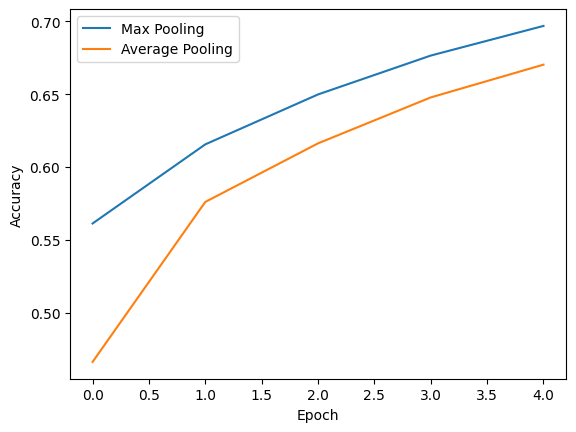

In [ ]:
# Visualize training history
plt.plot(history_max.history['accuracy'], label='Max Pooling')
plt.plot(history_average.history['accuracy'], label='Average Pooling')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()